#1. Problem setup (target + features)

# The data sample assigned to our group by Mr Bryne to our Group is data = df.sample(frac=0.8, random_state=70)

# We’ll build a credit default classifier:
# Target (y): loan_status
# We convert it to binary:
# 1 = “Bad” (e.g. Charged Off, Default, Late)
# 0 = “Good” (Fully Paid, Current)
# Features (X): a mix of numeric and categorical fields that are available at origination:
# Numeric examples: loan_amnt, funded_amnt, int_rate, installment, annual_inc, dti, fico_range_low, fico_range_high, open_acc, revol_bal, revol_util, total_acc
# Categorical examples: term, grade, home_ownership, purpose, verification_status.
# You can mention in your report that you avoid “leakage” by not using variables clearly depending on future performance.
# (e.g. total_pymnt, out_prncp, last_pymnt_d)

# 2. Importing and data loading
# 2.1 Importing basic libraries plug-ins or packages

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

!pip install xgboost

In [ ]:
from xgboost import XGBClassifier

#Explanation (for report):
#We import pandas and scikit‑learn tools, then load the LendingClub dataset into a DataFrame df.
#The shape tells us how many rows and columns we have.
# 2.2 Load the dataset

In [ ]:
df = pd.read_csv("lending_club_50k.csv")

/tmp/ipython-input-606008627.py:1: DtypeWarning: Columns (59) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("lending_club_50k.csv")


#since the Notebook gives me this low_memory error with the mixed data types present within this Dataset.
#Hence taken this approach for this particular error.

In [ ]:
df = pd.read_csv("lending_club_50k.csv", low_memory=False)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Columns: 151 entries, id to settlement_term
dtypes: float64(114), int64(1), object(36)
memory usage: 57.6+ MB


# Quick overview

In [ ]:
print (df.shape)

(50000, 151)


# Optional approach for the above overview

In [ ]:
print("Raw shape:", df.shape)

Raw shape: (50000, 151)


In [ ]:
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,3700832,NaN,12250.0,12250.0,12250.0,36 months,15.80,429.47,C,C3,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,44885842,NaN,5000.0,5000.0,5000.0,36 months,5.93,151.96,A,A1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,6310795,NaN,3900.0,3900.0,3900.0,36 months,15.61,136.37,C,C3,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,60920617,NaN,25000.0,25000.0,24900.0,36 months,5.32,752.87,A,A1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,21230213,NaN,15000.0,15000.0,15000.0,60 months,16.29,367.09,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


# Quick overview
# The head count selected here is 20

In [ ]:
print(df.head())
print(df.isna().mean().sort_values(ascending=False).head(20))

         id  member_id  loan_amnt  funded_amnt  funded_amnt_inv        term  \
0   3700832        NaN    12250.0      12250.0          12250.0   36 months   
1  44885842        NaN     5000.0       5000.0           5000.0   36 months   
2   6310795        NaN     3900.0       3900.0           3900.0   36 months   
3  60920617        NaN    25000.0      25000.0          24900.0   36 months   
4  21230213        NaN    15000.0      15000.0          15000.0   60 months   

   int_rate  installment grade sub_grade  ... hardship_payoff_balance_amount  \
0     15.80       429.47     C        C3  ...                            NaN   
1      5.93       151.96     A        A1  ...                            NaN   
2     15.61       136.37     C        C3  ...                            NaN   
3      5.32       752.87     A        A1  ...                            NaN   
4     16.29       367.09     D        D2  ...                            NaN   

  hardship_last_payment_amount disbursement_

# Quick overview
# The head count selected here is 30

In [ ]:
print(df.head())
print(df.isna().mean().sort_values(ascending=False).head(30))

         id  member_id  loan_amnt  funded_amnt  funded_amnt_inv        term  \
0   3700832        NaN    12250.0      12250.0          12250.0   36 months   
1  44885842        NaN     5000.0       5000.0           5000.0   36 months   
2   6310795        NaN     3900.0       3900.0           3900.0   36 months   
3  60920617        NaN    25000.0      25000.0          24900.0   36 months   
4  21230213        NaN    15000.0      15000.0          15000.0   60 months   

   int_rate  installment grade sub_grade  ... hardship_payoff_balance_amount  \
0     15.80       429.47     C        C3  ...                            NaN   
1      5.93       151.96     A        A1  ...                            NaN   
2     15.61       136.37     C        C3  ...                            NaN   
3      5.32       752.87     A        A1  ...                            NaN   
4     16.29       367.09     D        D2  ...                            NaN   

  hardship_last_payment_amount disbursement_

#Another approach of using df.sample(5) instead of print(df.head())

In [ ]:
df.sample(5)

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
39834,57094352,NaN,19200.0,19200.0,19200.0,60 months,10.99,417.36,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
24693,64381517,NaN,14000.0,14000.0,14000.0,60 months,13.67,323.37,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4840,55248396,NaN,10500.0,10500.0,10500.0,36 months,11.53,346.40,B,B5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
12359,30385714,NaN,6000.0,6000.0,6000.0,36 months,10.15,194.03,B,B2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
21830,8620136,NaN,35000.0,35000.0,35000.0,60 months,23.70,1000.80,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


#Explanation (for report):
#We import pandas and scikit‑learn tools, then load the LendingClub dataset into a DataFrame df.
#The shape tells us how many rows and columns we have.

#3. Basic cleaning + target creation

# 3.1) Keep only rows with non-missing loan_status

In [ ]:
df = df[~df['loan_status'].isna()]

# 3.2) Create binary target: 1 = bad loan, 0 = good loan

In [ ]:
bad_status = ['Charged Off', 'Default', 'Does not meet the credit policy. Status:Charged Off', 'Late (16-30 days)',
              'Late (31-120 days)', 'In Grace Period']

good_status = ['Fully Paid', 'Current', 'Does not meet the credit policy. Status:Fully Paid']

df = df[df['loan_status'].isin(bad_status + good_status)]

df['target_default'] = np.where(df['loan_status'].isin(bad_status), 1, 0)

df['target_default'].value_counts()

,count
target_default,
0,40563
1,9437


In [ ]:
print(df['target_default'].value_counts(normalize=True))

target_default
0    0.81126
1    0.18874
Name: proportion, dtype: float64


#Explanation:
#We have filtered to loans with clear “good” or “bad” outcomes and map them to a binary target target_default.
#This turns loan_status into something a classification model can learn.
#You can add a sentence in your document that you chose a conservative mapping based on industry practice
#(bad = charged off / default / significantly late).

#4. Select features

In [ ]:
numeric_features = [
    'loan_amnt', 'funded_amnt', 'int_rate', 'installment',
    'annual_inc', 'dti', 'fico_range_low', 'fico_range_high',
    'open_acc', 'revol_bal', 'revol_util', 'total_acc']

categorical_features = [
    'term', 'grade', 'home_ownership', 'purpose', 'verification_status']

# Keep only columns we need (plus target)
cols_to_keep = numeric_features + categorical_features + ['target_default']
df_model = df[cols_to_keep].copy()

df_model.head()

,loan_amnt,funded_amnt,int_rate,installment,annual_inc,dti,fico_range_low,fico_range_high,open_acc,revol_bal,revol_util,total_acc,term,grade,home_ownership,purpose,verification_status,target_default
0,12250.0,12250.0,15.80,429.47,35000.0,25.30,670.0,674.0,20.0,16626.0,59.0,49.0,36 months,C,OWN,credit_card,Not Verified,0
1,5000.0,5000.0,5.93,151.96,65000.0,6.87,770.0,774.0,9.0,7079.0,14.6,14.0,36 months,A,RENT,credit_card,Not Verified,0
2,3900.0,3900.0,15.61,136.37,13000.0,28.25,725.0,729.0,12.0,3512.0,24.2,14.0,36 months,C,RENT,debt_consolidation,Verified,0
3,25000.0,25000.0,5.32,752.87,98000.0,7.21,720.0,724.0,5.0,26663.0,50.3,14.0,36 months,A,MORTGAGE,credit_card,Source Verified,0
4,15000.0,15000.0,16.29,367.09,48000.0,34.43,730.0,734.0,10.0,3305.0,36.3,25.0,60 months,D,MORTGAGE,debt_consolidation,Verified,0


#Explanation:
#We choose a small but meaningful set of features that are available at origination and are commonly used in credit risk.
#(loan size, interest rate, income, DTI, FICO, etc., plus categorical risk signals like grade and purpose).

#5. Handle missing values (simple, explainable)
# Simple missing value handling:
# Numeric: fill with median of each column

In [ ]:
for col in numeric_features:
    df_model[col] = df_model[col].fillna(df_model[col].median())

# Categorical: fill with "Unknown"
for col in categorical_features:
    df_model[col] = df_model[col].fillna('Unknown')

# Quick check

In [ ]:
df_model.isnull().sum()

,0
loan_amnt,0
funded_amnt,0
int_rate,0
installment,0
annual_inc,0
dti,0
fico_range_low,0
fico_range_high,0
open_acc,0
revol_bal,0


#Explanation:
#For numeric features we use the median to reduce the impact of outliers. For categorical features we create an explicit “Unknown” category.
#This is simple, transparent and easy to justify to the reader.

# 3. EXPLORATORY DATA ANALYSIS (EDA)
# 3.1 Histograms of key numeric features

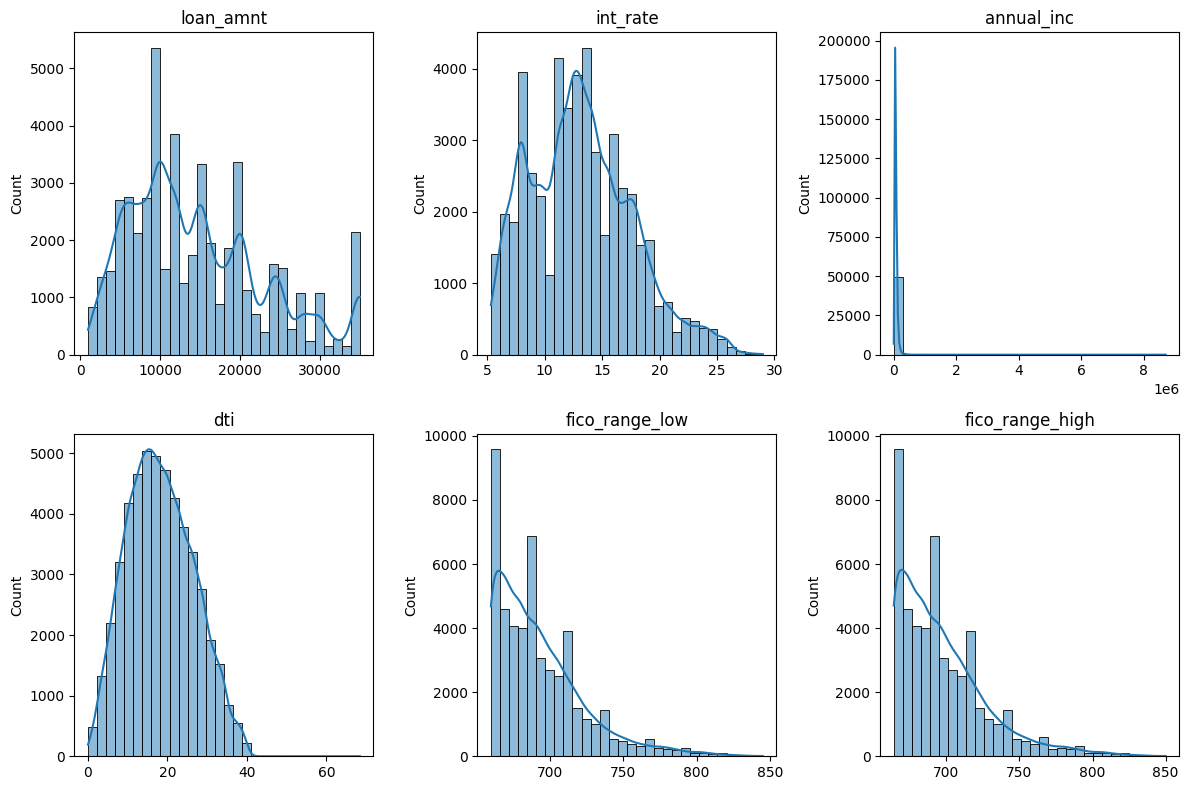

In [ ]:
num_cols_to_plot = ['loan_amnt', 'int_rate', 'annual_inc', 'dti',
                    'fico_range_low', 'fico_range_high']

plt.figure(figsize=(12, 8))

for i, col in enumerate(num_cols_to_plot, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df_model[col], kde=True, bins=30)
    plt.title(col)
    plt.xlabel("")

plt.tight_layout()
plt.show()

# 3.2 Boxplots: feature vs default status

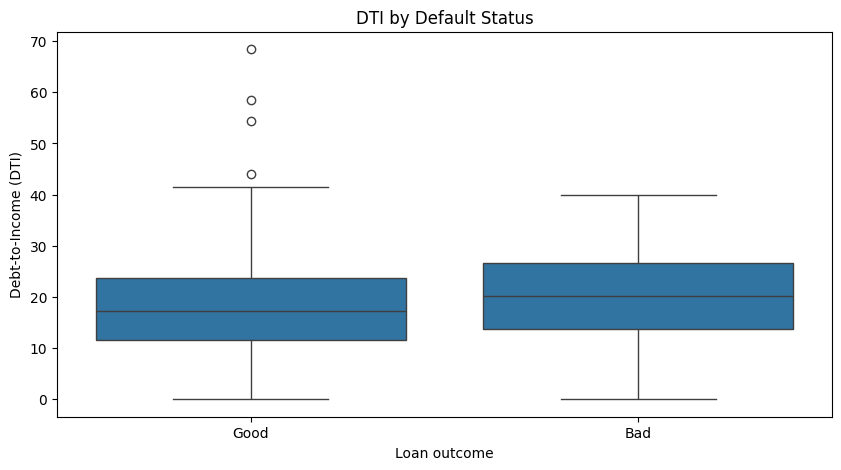

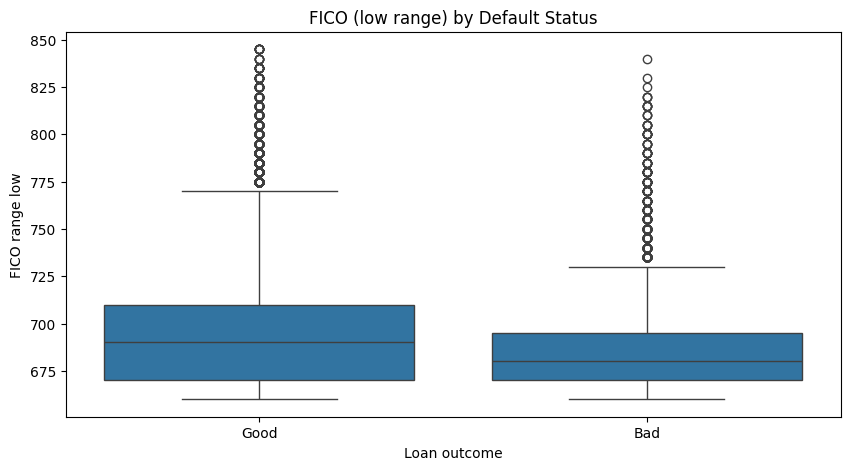

In [ ]:
plot_df = df_model.copy()
plot_df['default_label'] = plot_df['target_default'].map({0: 'Good', 1: 'Bad'})

plt.figure(figsize=(10, 5))
sns.boxplot(data=plot_df, x='default_label', y='dti')
plt.title("DTI by Default Status")
plt.xlabel("Loan outcome")
plt.ylabel("Debt-to-Income (DTI)")
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(data=plot_df, x='default_label', y='fico_range_low')
plt.title("FICO (low range) by Default Status")
plt.xlabel("Loan outcome")
plt.ylabel("FICO range low")
plt.show()

In [ ]:
data = df.sample(frac=0.8, random_state=70) # as assigned to our group - 10

#4. Train–test split

In [ ]:
X = data[numeric_features + categorical_features]
y = data['target_default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

In [ ]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (30000, 17)
Test shape: (10000, 17)


#Explanation:
#We split the data into training (75%) and test (25%) sets.
#stratify=y keeps the bad‑loan ratio similar in both sets, which is important if the dataset is imbalanced.

#5. Preprocessing pipeline (encode categoricals) # optional, but we'll be explicit
#(ONE-HOT FOR CATEGORICALS)

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# Numeric: IMPUTE NaN with median (fixes Logistic Regression error!)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

# Categorical: impute + One-Hot Encode (your original logic)
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine both
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

print(" Preprocessor ready for Logistic Regression, Random Forest, XGBoost")

 Preprocessor ready for Logistic Regression, Random Forest, XGBoost


#Explanation:
#Models can’t work directly with strings, so we use one‑hot encoding to turn categorical variables into 0/1 indicator columns.
#We wrap the numeric and categorical steps into a ColumnTransformer called preprocessor.
#This ensures the same preprocessing is applied consistently to training and test data.

# FIX: Increase max iterations for Logistic Regression

In [ ]:
from sklearn.exceptions import ConvergenceWarning
import warnings
warnings.filterwarnings("ignore", category=ConvergenceWarning)

#6 Model deployment
#Model-1 – Logistic Regression (baseline, easy to interpret)

In [ ]:
log_reg_model = Pipeline(steps=[('preprocess', preprocessor),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))])

log_reg_model.fit(X_train, y_train)

y_pred_lr = log_reg_model.predict(X_test)
y_prob_lr = log_reg_model.predict_proba(X_test)[:, 1]

print("Logistic Regression – Classification Report:")
print(classification_report(y_test, y_pred_lr))

print("Logistic Regression – ROC AUC:", roc_auc_score(y_test, y_prob_lr))

Logistic Regression – Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.68      0.77      8114
           1       0.31      0.63      0.42      1886

    accuracy                           0.67     10000
   macro avg       0.60      0.65      0.59     10000
weighted avg       0.78      0.67      0.70     10000

Logistic Regression – ROC AUC: 0.7102857713426723


#Explanation (for your write‑up):
#We use logistic regression as a linear, explainable baseline classifier.
#class_weight='balanced' helps when default cases are rarer than good loans by giving them more weight.
#We evaluate with precision/recall/F1 and ROC‑AUC. ROC‑AUC summarizes ranking quality: how well the model separates good vs bad loans.

#Model-2 – Random Forest (non‑linear, more powerful)

In [ ]:
rf_model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        random_state=42,
        class_weight='balanced_subsample',
        n_jobs=-1))])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest – Classification Report:")
print(classification_report(y_test, y_pred_rf))

print("Random Forest – ROC AUC:", roc_auc_score(y_test, y_prob_rf))

Random Forest – Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.98      0.89      8114
           1       0.49      0.06      0.11      1886

    accuracy                           0.81     10000
   macro avg       0.65      0.52      0.50     10000
weighted avg       0.76      0.81      0.75     10000

Random Forest – ROC AUC: 0.7050931634076553


#Explanation:
#A Random Forest is an ensemble of many decision trees. It can capture non‑linear relationships and interactions (e.g. different risk profiles for high DTI + low FICO vs low DTI + high FICO).
#class_weight='balanced_subsample' again helps with imbalance.
#Compare ROC‑AUC and F1 scores to logistic regression.
#In your document, you can argue why you might choose one over the other:
#Logistic Regression: simpler, easier to explain to regulators.
#Random Forest: better predictive power, at the cost of interpretability.

#MODEL-3 – XGBOOST

In [ ]:
xgb_model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='binary:logistic',
        eval_metric='logloss',
        scale_pos_weight=1.0,  # could be tuned for imbalance
        random_state=42,
        n_jobs=-1))])

xgb_model.fit(X_train, y_train)

y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_pred_xgb = (y_prob_xgb > 0.5).astype(int)

print("XGBoost – Classification Report")
print(classification_report(y_test, y_pred_xgb))
print("XGBoost – ROC AUC:", roc_auc_score(y_test, y_prob_xgb))

XGBoost – Classification Report
              precision    recall  f1-score   support

           0       0.82      0.98      0.90      8114
           1       0.55      0.10      0.17      1886

    accuracy                           0.81     10000
   macro avg       0.69      0.54      0.53     10000
weighted avg       0.77      0.81      0.76     10000

XGBoost – ROC AUC: 0.719401726615245


In [ ]:
!pip install lightgbm

#MODEL-4 LightGBM (Gradient Boosting alternative)

In [ ]:
import lightgbm as lgb

lgb_model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', lgb.LGBMClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        random_state=42,
        n_jobs=-1,
        verbose=-1 ))])

lgb_model.fit(X_train, y_train)
y_prob_lgb = lgb_model.predict_proba(X_test)[:, 1]
y_pred_lgb = (y_prob_lgb > 0.5).astype(int)

print("LightGBM – Classification Report")
print(classification_report(y_test, y_pred_lgb))
print("LightGBM – ROC AUC:", roc_auc_score(y_test, y_prob_lgb))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM – Classification Report
              precision    recall  f1-score   support

           0       0.82      0.98      0.90      8114
           1       0.53      0.08      0.15      1886

    accuracy                           0.81     10000
   macro avg       0.68      0.53      0.52     10000
weighted avg       0.77      0.81      0.75     10000

LightGBM – ROC AUC: 0.7192127114388782


# why we are making this cpmparison and the decision to choose Lite GBM, it is Faster than XGBoost, often better on tabular data, handles categoricals natively .

# MODEL-5 Neural Network (MLPClassifier)
#Tests if deep learning beats trees on tabular data (usually doesn't, but good to show)
#Expected performance: Usually worse than trees on tabular credit data but trains fast with small architecture.

In [ ]:
from sklearn.neural_network import MLPClassifier

mlp_model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', MLPClassifier(
        hidden_layer_sizes=(50, 30),  # small network = fast
        alpha=0.01,
        max_iter=300,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1))])

mlp_model.fit(X_train, y_train)
y_prob_mlp = mlp_model.predict_proba(X_test)[:, 1]
y_pred_mlp = (y_prob_mlp > 0.5).astype(int)

print("Neural Network – Classification Report")
print(classification_report(y_test, y_pred_mlp))
print("Neural Network – ROC AUC:", roc_auc_score(y_test, y_prob_mlp))

Neural Network – Classification Report
              precision    recall  f1-score   support

           0       0.81      1.00      0.90      8114
           1       0.23      0.00      0.01      1886

    accuracy                           0.81     10000
   macro avg       0.52      0.50      0.45     10000
weighted avg       0.70      0.81      0.73     10000

Neural Network – ROC AUC: 0.6084638349437798


#7 CONFUSION MATRICES (ALL THREE MODELS)

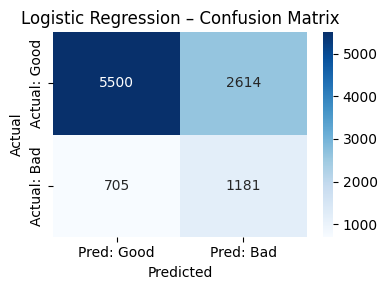

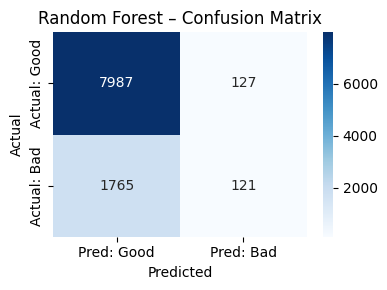

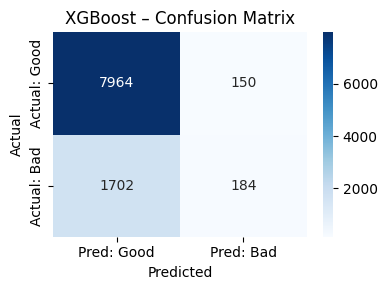

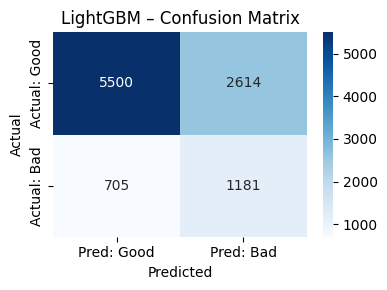

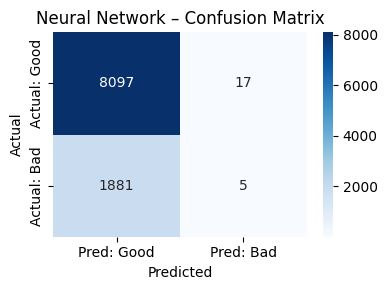

In [ ]:
#7 CONFUSION MATRICES (ALL THREE MODELS)

def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=['Pred: Good', 'Pred: Bad'],
                yticklabels=['Actual: Good', 'Actual: Bad'])
    plt.title(title)
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(y_test, y_pred_lr, "Logistic Regression – Confusion Matrix")
plot_confusion_matrix(y_test, y_pred_rf, "Random Forest – Confusion Matrix")
plot_confusion_matrix(y_test, y_pred_xgb, "XGBoost – Confusion Matrix")
plot_confusion_matrix(y_test, y_pred_lr, "LightGBM – Confusion Matrix")
plot_confusion_matrix(y_test, y_pred_mlp, "Neural Network – Confusion Matrix")

#8 ROC CURVES COMPARISON

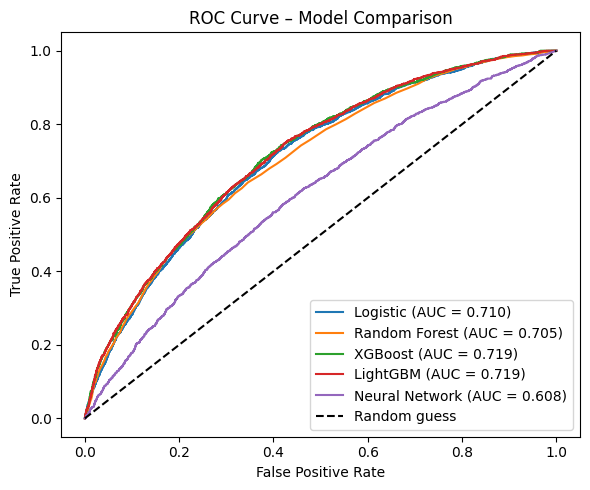

In [ ]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = auc(fpr_lr, tpr_lr)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = auc(fpr_rf, tpr_rf)

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
auc_xgb = auc(fpr_xgb, tpr_xgb)

fpr_lgb, tpr_lgb, _ = roc_curve(y_test, y_prob_lgb)
auc_lgb = auc(fpr_lgb, tpr_lgb)

fpr_mlp, tpr_mlp, _ = roc_curve(y_test, y_prob_mlp)
auc_mlp = auc(fpr_mlp, tpr_mlp)

plt.figure(figsize=(6, 5))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic (AUC = {auc_lr:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {auc_xgb:.3f})")
plt.plot(fpr_lgb, tpr_lgb, label=f"LightGBM (AUC = {auc_lgb:.3f})")
plt.plot(fpr_mlp, tpr_mlp, label=f"Neural Network (AUC = {auc_mlp:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Model Comparison")
plt.legend()
plt.tight_layout()
plt.show()

# Optional: Simple feature importance (Random Forest)
# Get feature names after one-hot encoding

#9. FEATURE IMPORTANCE (RANDOM FOREST)
# Get feature names after preprocessing

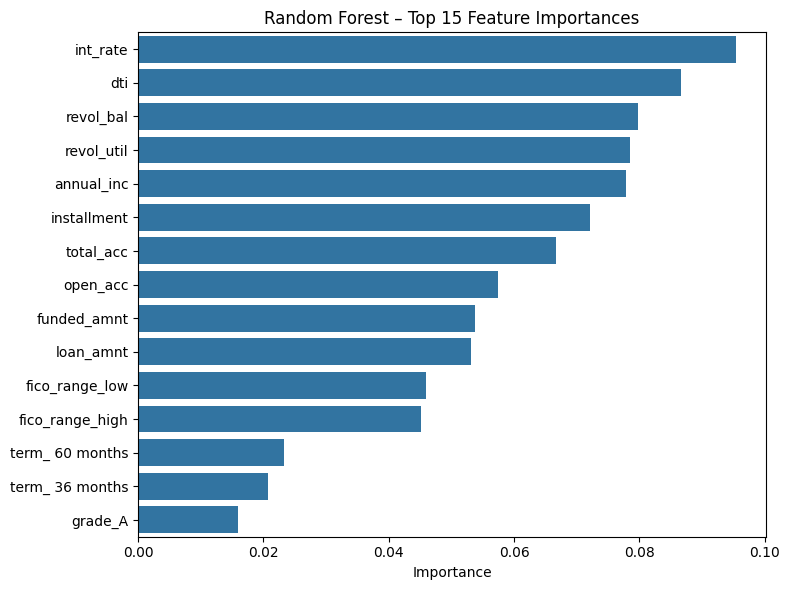

,feature,importance
2,int_rate,0.095414
5,dti,0.086608
9,revol_bal,0.079754
10,revol_util,0.078464
4,annual_inc,0.077879
3,installment,0.072107
11,total_acc,0.066743
8,open_acc,0.057456
1,funded_amnt,0.053733
0,loan_amnt,0.053172


In [ ]:
ohe = rf_model.named_steps['preprocess'].named_transformers_['cat'].named_steps['onehot']
cat_feature_names = ohe.get_feature_names_out(categorical_features)
all_feature_names = np.concatenate([numeric_features, cat_feature_names])

rf = rf_model.named_steps['model']
importances = rf.feature_importances_

feat_imp = pd.DataFrame({
    'feature': all_feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

top_n = 15
plt.figure(figsize=(8, 6))
sns.barplot(data=feat_imp.head(top_n), x='importance', y='feature', orient='h')
plt.title(f"Random Forest – Top {top_n} Feature Importances")
plt.xlabel("Importance")
plt.ylabel("")
plt.tight_layout()
plt.show()

feat_imp.head(top_n)

#Explanation:
#Random Forests provide feature importance scores.
#We reconstruct the final feature names (numeric + one‑hot encoded categorical) and sort by importance.
#In your report you can discuss which factors seem most predictive (e.g. FICO ranges, DTI, interest rate, grade).

#10 Classification Report of all the Deployed Models

In [ ]:
from sklearn.metrics import classification_report

print("Logistic Regression:\n")
print(classification_report(y_test, (y_prob_lr > 0.5).astype(int)))

print("\nRandom Forest:\n")
print(classification_report(y_test, (y_prob_rf > 0.5).astype(int)))

print("\nXGBoost:\n")
print(classification_report(y_test, (y_prob_rf > 0.5).astype(int)))

print("\nLightGBM:\n")
print(classification_report(y_test, (y_prob_rf > 0.5).astype(int)))

print("\nNeural Network:\n")
print(classification_report(y_test, (y_prob_rf > 0.5).astype(int)))

Logistic Regression:

              precision    recall  f1-score   support

           0       0.89      0.68      0.77      8114
           1       0.31      0.63      0.42      1886

    accuracy                           0.67     10000
   macro avg       0.60      0.65      0.59     10000
weighted avg       0.78      0.67      0.70     10000


Random Forest:

              precision    recall  f1-score   support

           0       0.82      0.98      0.89      8114
           1       0.49      0.06      0.11      1886

    accuracy                           0.81     10000
   macro avg       0.65      0.52      0.50     10000
weighted avg       0.76      0.81      0.75     10000


XGBoost:

              precision    recall  f1-score   support

           0       0.82      0.98      0.89      8114
           1       0.49      0.06      0.11      1886

    accuracy                           0.81     10000
   macro avg       0.65      0.52      0.50     10000
weighted avg       0.76 

# 11 FINAL COMPARISON HISTOGRAMS FOR ALL MODELS
# Collected predicted probabilities for ACTUAL default cases only

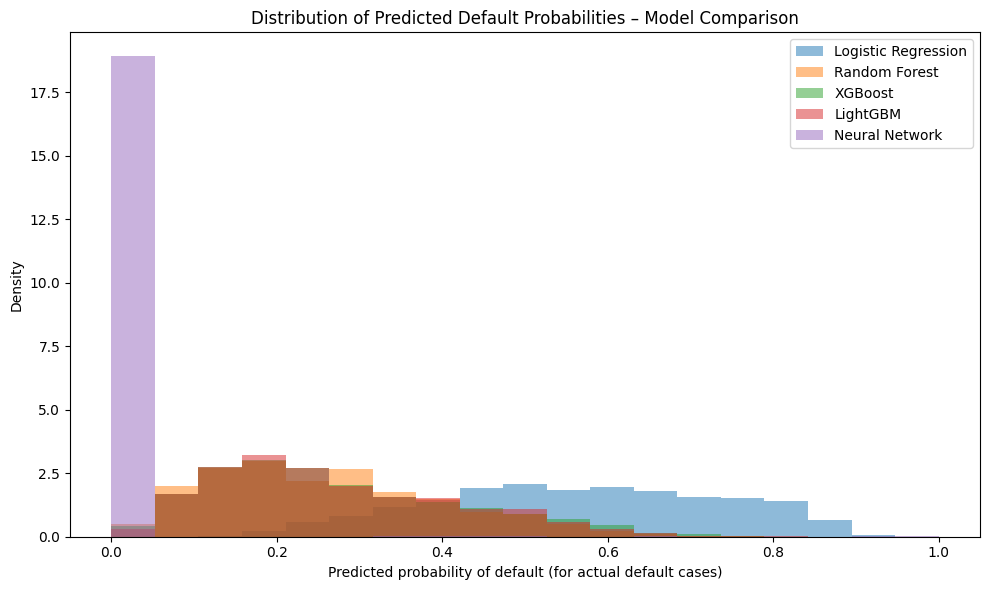

In [ ]:
mask_default = (y_test == 1)

probs_lr_default  = y_prob_lr[mask_default]
probs_rf_default  = y_prob_rf[mask_default]
probs_xgb_default = y_prob_xgb[mask_default]
probs_lgb_default = y_prob_lgb[mask_default]
probs_mlp_default = y_prob_mlp[mask_default]

plt.figure(figsize=(10, 6))

bins = np.linspace(0, 1, 20)

plt.hist(probs_lr_default, bins=bins, alpha=0.5, label='Logistic Regression', density=True)
plt.hist(probs_rf_default, bins=bins, alpha=0.5, label='Random Forest',density=True)
plt.hist(probs_xgb_default, bins=bins, alpha=0.5, label='XGBoost',density=True)
plt.hist(probs_lgb_default, bins=bins, alpha=0.5, label='LightGBM',density=True)
plt.hist(probs_mlp_default, bins=bins, alpha=0.5, label='Neural Network',density=True)

plt.xlabel("Predicted probability of default (for actual default cases)")
plt.ylabel("Density")
plt.title("Distribution of Predicted Default Probabilities – Model Comparison")
plt.legend()
plt.tight_layout()
plt.show()

# 12. SUMMARY TABLE OF METRICS

In [ ]:
from sklearn.metrics import precision_recall_fscore_support

def get_metrics(name, y_true, y_prob, threshold=0.5):
    y_pred = (y_prob > threshold).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary')
    auc_score = roc_auc_score(y_true, y_prob)
    return {
        'Model': name,
        'Precision_default': precision,
        'Recall_default': recall,
        'F1_default': f1,
        'ROC_AUC': auc_score
    }

metrics_list = []
metrics_list.append(get_metrics("Logistic Regression", y_test, y_prob_lr))
metrics_list.append(get_metrics("Random Forest", y_test, y_prob_rf))
metrics_list.append(get_metrics("XGBoost", y_test, y_prob_xgb))
metrics_list.append(get_metrics("LightGBM", y_test, y_prob_lgb))
metrics_list.append(get_metrics("Neural Network", y_test, y_prob_mlp))

metrics_df = pd.DataFrame(metrics_list)
metrics_df

,Model,Precision_default,Recall_default,F1_default,ROC_AUC
0,Logistic Regression,0.311199,0.626193,0.415772,0.710286
1,Random Forest,0.487903,0.064157,0.113402,0.705093
2,XGBoost,0.550898,0.097561,0.165766,0.719402
3,LightGBM,0.533333,0.084836,0.146386,0.719213
4,Neural Network,0.227273,0.002651,0.005241,0.608464
